# 09 - ARIMA-family PLR robustness check

This notebook estimates module-level performance loss rates using ARIMA-family time-series regression.

ARIMA is used as a robustness check rather than as a primary PLR estimator. The purpose is not to forecast future module performance, but to test whether the estimated long-term trend remains broadly consistent when monthly autocorrelation and seasonal residual structure are considered.

The model is implemented using SARIMAX with a deterministic linear time trend. The input is the monthly \(PR_\mathrm{DC,25C}\) time series prepared in the PLR input pipeline.

The main outputs are:

1. ARIMA-family PLR estimates for the main g200 dataset
2. selected ARIMA model orders
3. fitted monthly ARIMA series
4. deterministic ARIMA trend components
5. residual diagnostics
6. ensemble-ready ARIMA results

## 1. Imports and plotting style

In [1]:
from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.statespace.sarimax import SARIMAX
from matplotlib.lines import Line2D
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 11,
    "legend.title_fontsize": 11,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 12
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 11

## 2. Paths

In [2]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data_processed"
PLR_INPUT_DIR = DATA_PROCESSED_DIR / "plr_final_inputs"
ARIMA_OUTPUT_DIR = DATA_PROCESSED_DIR / "arima_outputs"

FINAL_FIG_DIR = PROJECT_ROOT / "figures" / "final figures"
FINAL_TABLE_DIR = PROJECT_ROOT / "tables" / "final tables"

for folder in [ARIMA_OUTPUT_DIR, FINAL_FIG_DIR, FINAL_TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MONTHLY_INPUT_PATHS = {
    "g200": PLR_INPUT_DIR / "g200_monthly_pr25c_filtered_for_plr.parquet",
    "g400": PLR_INPUT_DIR / "g400_monthly_pr25c_filtered_for_plr.parquet",
}

DATASET_LABELS = {
    "g200": r"$G_\mathrm{POA} \geq 200$ W/m$^2$",
    "g400": r"$G_\mathrm{POA} \geq 400$ W/m$^2$",
}

MAIN_DATASET = "g200"
SENSITIVITY_DATASET = "g400"

print("Project root:", PROJECT_ROOT)
print("PLR input folder:", PLR_INPUT_DIR)
print("ARIMA output folder:", ARIMA_OUTPUT_DIR)
print("Figure folder:", FINAL_FIG_DIR)
print("Table folder:", FINAL_TABLE_DIR)

for dataset_name, path in MONTHLY_INPUT_PATHS.items():
    print(f"{dataset_name} input exists:", path.exists(), "|", path)

Project root: C:\Users\amina\Thesis\Final Pipeline
PLR input folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs
ARIMA output folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\arima_outputs
Figure folder: C:\Users\amina\Thesis\Final Pipeline\figures\final figures
Table folder: C:\Users\amina\Thesis\Final Pipeline\tables\final tables
g200 input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\g200_monthly_pr25c_filtered_for_plr.parquet
g400 input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\g400_monthly_pr25c_filtered_for_plr.parquet


## 3. Constants and module metadata

ARIMA-family modelling is applied to monthly \(PR_\mathrm{DC,25C}\). The model grid allows limited non-seasonal and seasonal autoregressive and moving-average structure, while keeping differencing fixed at zero because PLR is estimated through an explicit deterministic time trend.

In [3]:
MAIN_METRIC = "PR_25C"
TIME_COL = "Month_Start"

MIN_MONTHS_FOR_ARIMA = 24

DAYS_PER_YEAR = 365.25
CONFIDENCE_LEVEL = 0.95
Z_95 = 1.96

# Candidate ARIMA-family model orders
P_RANGE = [0, 1, 2]
Q_RANGE = [0, 1, 2]

SEASONAL_P_RANGE = [0, 1]
SEASONAL_Q_RANGE = [0, 1]

D_ARIMA = 0
D_SEASONAL = 0
SEASONAL_PERIOD = 12

MODEL_SELECTION_CRITERION = "AIC"

BLACK = "#222222"
GREY = "#BDBDBD"

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
    "Unknown": "#666666",
}

module_meta = pd.DataFrame({
    "Module_ID": list(range(1, 11)),
    "Type": [
        "PID/Reference",
        "Reference",
        "uCrack",
        "uCrack",
        "Reference",
        "uCrack",
        "uCrack",
        "uCrack",
        "uCrack",
        "Reference",
    ],
})

MODULE_TYPE_MAP = dict(zip(module_meta["Module_ID"], module_meta["Type"]))

display(module_meta)

,Module_ID,Type
0,1,PID/Reference
1,2,Reference
2,3,uCrack
3,4,uCrack
4,5,Reference
5,6,uCrack
6,7,uCrack
7,8,uCrack
8,9,uCrack
9,10,Reference


## 4. Helper functions

In [4]:
def save_fig(filename, fig=None):
    """
    Save figure to the final figure directory.
    """
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def format_year_axis(ax):
    """
    Format x-axis with annual ticks.
    """
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)


def strip_timezone(series):
    """
    Convert a datetime series to timezone-naive timestamps.
    """
    series = pd.to_datetime(series)

    if getattr(series.dt, "tz", None) is not None:
        return series.dt.tz_convert(None)

    return series


def normalise_type_label(value):
    """
    Normalise module category labels across input files.
    """
    if pd.isna(value):
        return "Unknown"

    value_str = str(value).strip()

    if value_str in TYPE_COLORS:
        return value_str

    value_low = value_str.lower()

    if "pid" in value_low:
        return "PID/Reference"
    if "ucrack" in value_low or "microcrack" in value_low or "crack" in value_low:
        return "uCrack"
    if "ref" in value_low:
        return "Reference"

    return "Unknown"


def module_category_legend_handles():
    """
    Legend handles for module categories.
    """
    return [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="Reference",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["uCrack"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="uCrack",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["PID/Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="PID/Reference",
        ),
    ]

## 5. Load monthly PLR input datasets

The ARIMA-family robustness check is applied to the monthly \(PR_\mathrm{DC,25C}\) datasets. The g200 dataset is the main input, while g400 is retained as an irradiance-threshold sensitivity dataset.

In [5]:
monthly_datasets = {}

for dataset_name, path in MONTHLY_INPUT_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing monthly input for {dataset_name}: {path}")

    df = pd.read_parquet(path)

    if "Month_Start" in df.columns:
        df["Month_Start"] = strip_timezone(df["Month_Start"])
    elif "YearMonth" in df.columns:
        df["Month_Start"] = pd.to_datetime(df["YearMonth"].astype(str))
    else:
        raise ValueError(f"{dataset_name}: missing Month_Start or YearMonth column.")

    if "YearMonth" not in df.columns:
        df["YearMonth"] = df["Month_Start"].dt.to_period("M").astype(str)

    if "Type" not in df.columns:
        df = df.merge(module_meta, on="Module_ID", how="left")

    df["Type"] = df["Type"].apply(normalise_type_label)
    df["dataset"] = dataset_name
    df["dataset_label"] = DATASET_LABELS[dataset_name]
    df["module_color"] = df["Type"].map(TYPE_COLORS).fillna(TYPE_COLORS["Unknown"])

    df = df.sort_values(["Module_ID", "Month_Start"]).reset_index(drop=True)

    required_cols = ["Module_ID", "Type", "Month_Start", "YearMonth", MAIN_METRIC]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"{dataset_name}: missing required columns: {missing_cols}")

    duplicate_count = df.duplicated(subset=["Module_ID", "Month_Start"]).sum()
    if duplicate_count > 0:
        raise ValueError(f"{dataset_name}: duplicate Module_ID-Month_Start rows found.")

    monthly_datasets[dataset_name] = df

    print(f"{dataset_name} loaded")
    print("Shape:", df.shape)
    print("Month range:", df["Month_Start"].min(), "to", df["Month_Start"].max())
    print("Modules:", sorted(df["Module_ID"].unique()))
    print("-" * 80)

g200 loaded
Shape: (416, 37)
Month range: 2017-01-01 00:00:00 to 2021-10-01 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------
g400 loaded
Shape: (356, 37)
Month range: 2017-04-01 00:00:00 to 2021-10-01 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------


## 6. Input summary

This summary records the number of monthly records available in each ARIMA input dataset.

In [6]:
monthly_input_summary = []

for dataset_name, df in monthly_datasets.items():
    monthly_input_summary.append({
        "Dataset": dataset_name,
        "Input definition": DATASET_LABELS[dataset_name],
        "Monthly records": len(df),
        "Modules": df["Module_ID"].nunique(),
        "First month": df["Month_Start"].min(),
        "Last month": df["Month_Start"].max(),
        "Median PR_DC,25C": df[MAIN_METRIC].median(),
        "Minimum PR_DC,25C": df[MAIN_METRIC].min(),
        "Maximum PR_DC,25C": df[MAIN_METRIC].max(),
    })

monthly_input_summary = pd.DataFrame(monthly_input_summary)

display(monthly_input_summary)

MONTHLY_INPUT_SUMMARY_PATH = FINAL_TABLE_DIR / "arima_monthly_input_summary.csv"

monthly_input_summary.to_csv(
    MONTHLY_INPUT_SUMMARY_PATH,
    index=False,
)

print("Saved monthly input summary:", MONTHLY_INPUT_SUMMARY_PATH)

,Dataset,Input definition,Monthly records,Modules,First month,Last month,"Median PR_DC,25C","Minimum PR_DC,25C","Maximum PR_DC,25C"
0,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,416,10,2017-01-01,2021-10-01,0.945307,0.650984,1.003170
1,g400,$G_\mathrm{POA} \geq 400$ W/m$^2$,356,10,2017-04-01,2021-10-01,0.950341,0.652970,1.013898


Saved monthly input summary: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\arima_monthly_input_summary.csv


## 7. Regularise monthly series for ARIMA

ARIMA-family modelling requires a regular monthly time series. Each module is therefore reindexed to a complete monthly sequence between its first and last available month.

Internal missing \(PR_\mathrm{DC,25C}\) values are linearly interpolated for ARIMA fitting only. These months are flagged in the output.

In [7]:
def regularise_monthly_series(module_df):
    """
    Convert one module's monthly series to a complete monthly index.

    Internal missing PR_DC,25C values are linearly interpolated for ARIMA-family fitting.
    Interpolated months are flagged.
    """
    module_df = module_df.sort_values("Month_Start").copy()

    module_id = int(module_df["Module_ID"].iloc[0])
    module_type = module_df["Type"].iloc[0]
    dataset_name = module_df["dataset"].iloc[0]
    dataset_label = module_df["dataset_label"].iloc[0]
    module_color = module_df["module_color"].iloc[0]

    month_index = pd.date_range(
        start=module_df["Month_Start"].min(),
        end=module_df["Month_Start"].max(),
        freq="MS",
    )

    regular = (
        module_df
        .set_index("Month_Start")
        .reindex(month_index)
        .rename_axis("Month_Start")
        .reset_index()
    )

    regular["Module_ID"] = module_id
    regular["Type"] = module_type
    regular["dataset"] = dataset_name
    regular["dataset_label"] = dataset_label
    regular["module_color"] = module_color
    regular["YearMonth"] = regular["Month_Start"].dt.to_period("M").astype(str)

    regular["PR_25C_observed"] = regular[MAIN_METRIC]
    regular["observed_month"] = regular["PR_25C_observed"].notna()

    regular["PR_25C_arima"] = (
        regular
        .set_index("Month_Start")["PR_25C_observed"]
        .interpolate(method="time", limit_area="inside")
        .values
    )

    regular["imputed_for_arima"] = (
        regular["PR_25C_observed"].isna()
        & regular["PR_25C_arima"].notna()
    )

    regular["module_start_month"] = regular["Month_Start"].min()
    regular["time_days"] = (
        regular["Month_Start"] - regular["module_start_month"]
    ).dt.days
    regular["time_years"] = regular["time_days"] / DAYS_PER_YEAR

    return regular

In [8]:
arima_regular_datasets = {}

for dataset_name, df in monthly_datasets.items():
    regularised_modules = []

    for module_id, module_df in df.groupby("Module_ID"):
        regularised_modules.append(regularise_monthly_series(module_df))

    regular_df = (
        pd.concat(regularised_modules, ignore_index=True)
        .sort_values(["Module_ID", "Month_Start"])
        .reset_index(drop=True)
    )

    arima_regular_datasets[dataset_name] = regular_df

    print(f"{dataset_name} regularised")
    print("Shape:", regular_df.shape)
    print("Observed months:", int(regular_df["observed_month"].sum()))
    print("Imputed months:", int(regular_df["imputed_for_arima"].sum()))
    print("-" * 80)

g200 regularised
Shape: (578, 44)
Observed months: 416
Imputed months: 162
--------------------------------------------------------------------------------
g400 regularised
Shape: (545, 44)
Observed months: 356
Imputed months: 189
--------------------------------------------------------------------------------


## 8. Regularisation summary

This table records observed and interpolated monthly support for each module before ARIMA-family fitting.

In [9]:
regular_summary_tables = []

for dataset_name, regular_df in arima_regular_datasets.items():
    summary = (
        regular_df
        .groupby(["Module_ID", "Type"], as_index=False)
        .agg(
            n_months_regular=("PR_25C_arima", "size"),
            n_months_observed=("observed_month", "sum"),
            n_months_imputed=("imputed_for_arima", "sum"),
            n_missing_after_interpolation=("PR_25C_arima", lambda x: x.isna().sum()),
            first_month=("Month_Start", "min"),
            last_month=("Month_Start", "max"),
        )
    )

    summary["pct_months_imputed"] = (
        100 * summary["n_months_imputed"] / summary["n_months_regular"]
    )

    summary["eligible_for_arima"] = (
        (summary["n_months_observed"] >= MIN_MONTHS_FOR_ARIMA)
        & (summary["n_missing_after_interpolation"] == 0)
    )

    summary.insert(0, "dataset", dataset_name)
    regular_summary_tables.append(summary)

arima_regularisation_summary = pd.concat(regular_summary_tables, ignore_index=True)

display(arima_regularisation_summary)

ARIMA_REGULARISATION_SUMMARY_PATH = FINAL_TABLE_DIR / "arima_regularisation_summary.csv"

arima_regularisation_summary.to_csv(
    ARIMA_REGULARISATION_SUMMARY_PATH,
    index=False,
)

print("Saved regularisation summary:", ARIMA_REGULARISATION_SUMMARY_PATH)

if not arima_regularisation_summary["eligible_for_arima"].all():
    display(arima_regularisation_summary.loc[~arima_regularisation_summary["eligible_for_arima"]])
    raise ValueError("At least one module-dataset combination is not eligible for ARIMA-family modelling.")

,dataset,Module_ID,Type,n_months_regular,n_months_observed,n_months_imputed,n_missing_after_interpolation,first_month,last_month,pct_months_imputed,eligible_for_arima
0,g200,1,PID/Reference,58,42,16,0,2017-01-01,2021-10-01,27.586207,True
1,g200,2,Reference,58,43,15,0,2017-01-01,2021-10-01,25.862069,True
2,g200,3,uCrack,58,42,16,0,2017-01-01,2021-10-01,27.586207,True
3,g200,4,uCrack,58,43,15,0,2017-01-01,2021-10-01,25.862069,True
4,g200,5,Reference,58,42,16,0,2017-01-01,2021-10-01,27.586207,True
5,g200,6,uCrack,58,42,16,0,2017-01-01,2021-10-01,27.586207,True
6,g200,7,uCrack,58,41,17,0,2017-01-01,2021-10-01,29.310345,True
7,g200,8,uCrack,58,40,18,0,2017-01-01,2021-10-01,31.034483,True
8,g200,9,uCrack,57,41,16,0,2017-01-01,2021-09-01,28.070175,True
9,g200,10,Reference,57,40,17,0,2017-01-01,2021-09-01,29.824561,True


Saved regularisation summary: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\arima_regularisation_summary.csv


## 9. Define ARIMA-family model grid

A compact SARIMAX grid is used for each module. The model includes a deterministic constant and linear time trend through exogenous regressors. The selected model is the converged candidate with the lowest AIC.

In [10]:
def generate_sarimax_candidate_orders():
    """
    Generate candidate SARIMAX model orders.
    """
    candidates = []

    for p, q, seasonal_p, seasonal_q in itertools.product(
        P_RANGE,
        Q_RANGE,
        SEASONAL_P_RANGE,
        SEASONAL_Q_RANGE,
    ):
        order = (p, D_ARIMA, q)
        seasonal_order = (
            seasonal_p,
            D_SEASONAL,
            seasonal_q,
            SEASONAL_PERIOD,
        )

        candidates.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "p": p,
            "d": D_ARIMA,
            "q": q,
            "P": seasonal_p,
            "D": D_SEASONAL,
            "Q": seasonal_q,
            "s": SEASONAL_PERIOD,
        })

    return candidates


SARIMAX_CANDIDATES = generate_sarimax_candidate_orders()

print("Number of candidate SARIMAX models:", len(SARIMAX_CANDIDATES))
display(pd.DataFrame(SARIMAX_CANDIDATES).head())

Number of candidate SARIMAX models: 36


,order,seasonal_order,p,d,q,P,D,Q,s
0,"(0, 0, 0)","(0, 0, 0, 12)",0,0,0,0,0,0,12
1,"(0, 0, 0)","(0, 0, 1, 12)",0,0,0,0,0,1,12
2,"(0, 0, 0)","(1, 0, 0, 12)",0,0,0,1,0,0,12
3,"(0, 0, 0)","(1, 0, 1, 12)",0,0,0,1,0,1,12
4,"(0, 0, 1)","(0, 0, 0, 12)",0,0,1,0,0,0,12


## 10. Fit ARIMA-family models

For each module, all candidate SARIMAX models are fitted. The selected model is the converged candidate with the lowest AIC.

The PLR estimate is calculated from the deterministic time-trend coefficient:

\[
PLR_\mathrm{ARIMA} = 100 \times \frac{\theta_1}{\theta_0}
\]

where \(\theta_1\) is the fitted annual time-trend coefficient and \(\theta_0\) is the fitted intercept. Since time is expressed in years, no additional annualisation factor is required.

In [11]:
def prepare_sarimax_inputs(module_df):
    """
    Prepare one module's ARIMA-family input series.

    Endogenous variable:
    - monthly PR_DC,25C

    Exogenous regressors:
    - constant
    - time in years
    """
    module_df = module_df.sort_values("Month_Start").copy()

    model_df = (
        module_df[["Month_Start", "PR_25C_arima", "time_years"]]
        .dropna()
        .copy()
    )

    model_df = model_df.set_index("Month_Start").asfreq("MS")

    y = model_df["PR_25C_arima"].astype(float)

    exog = pd.DataFrame(
        {
            "const": 1.0,
            "time_years": model_df["time_years"].astype(float),
        },
        index=model_df.index,
    )

    return model_df, y, exog

In [12]:
def fit_sarimax_candidate(y, exog, candidate):
    """
    Fit one SARIMAX candidate safely.

    Returns the fitted result if successful and converged.
    Otherwise returns None.
    """
    try:
        model = SARIMAX(
            endog=y,
            exog=exog,
            order=candidate["order"],
            seasonal_order=candidate["seasonal_order"],
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
            initialization="approximate_diffuse",
        )

        fitted = model.fit(
            disp=False,
            maxiter=300,
            method="lbfgs",
        )

        converged = bool(fitted.mle_retvals.get("converged", False))

        if not converged:
            return None

        if not np.isfinite(fitted.aic):
            return None

        if "const" not in fitted.params.index or "time_years" not in fitted.params.index:
            return None

        return fitted

    except Exception:
        return None

In [13]:
def fit_arima_family_module(module_df, dataset_name):
    """
    Fit SARIMAX candidate models for one module and select the lowest-AIC model.

    Returns:
    - selected model result row
    - fitted monthly output
    - candidate model table
    """
    module_df = module_df.sort_values("Month_Start").copy()

    module_id = int(module_df["Module_ID"].iloc[0])
    module_type = module_df["Type"].iloc[0]
    module_color = module_df["module_color"].iloc[0]
    dataset_label = module_df["dataset_label"].iloc[0]

    n_observed = int(module_df["observed_month"].sum())
    n_imputed = int(module_df["imputed_for_arima"].sum())
    n_regular = int(len(module_df))
    n_missing_after_interpolation = int(module_df["PR_25C_arima"].isna().sum())

    eligible = (
        (n_observed >= MIN_MONTHS_FOR_ARIMA)
        and (n_missing_after_interpolation == 0)
    )

    if not eligible:
        raise ValueError(f"Module {module_id}, {dataset_name} is not eligible for ARIMA-family modelling.")

    model_df, y, exog = prepare_sarimax_inputs(module_df)

    candidate_rows = []
    fitted_candidates = []

    for candidate in SARIMAX_CANDIDATES:
        fitted = fit_sarimax_candidate(y, exog, candidate)

        candidate_row = {
            "dataset": dataset_name,
            "Module_ID": module_id,
            "Type": module_type,
            "order": candidate["order"],
            "seasonal_order": candidate["seasonal_order"],
            "p": candidate["p"],
            "d": candidate["d"],
            "q": candidate["q"],
            "P": candidate["P"],
            "D": candidate["D"],
            "Q": candidate["Q"],
            "s": candidate["s"],
            "converged": fitted is not None,
            "aic": fitted.aic if fitted is not None else np.nan,
            "bic": fitted.bic if fitted is not None else np.nan,
        }

        candidate_rows.append(candidate_row)

        if fitted is not None:
            fitted_candidates.append((candidate, fitted))

    candidate_table = pd.DataFrame(candidate_rows)

    if len(fitted_candidates) == 0:
        raise ValueError(f"No converged ARIMA-family candidate for Module {module_id}, {dataset_name}.")

    selected_candidate, selected_fit = min(
        fitted_candidates,
        key=lambda item: item[1].aic,
    )

    intercept = selected_fit.params["const"]
    slope_per_year = selected_fit.params["time_years"]
    slope_se = selected_fit.bse["time_years"]
    slope_p_value = selected_fit.pvalues["time_years"]

    slope_ci_low = slope_per_year - Z_95 * slope_se
    slope_ci_high = slope_per_year + Z_95 * slope_se

    plr = 100 * slope_per_year / intercept
    plr_ci_low = 100 * slope_ci_low / intercept
    plr_ci_high = 100 * slope_ci_high / intercept

    plr_ci_low, plr_ci_high = sorted([plr_ci_low, plr_ci_high])

    fitted_values = selected_fit.fittedvalues.copy()
    residuals = y - fitted_values

    fitted_df = model_df.reset_index().copy()
    fitted_df["dataset"] = dataset_name
    fitted_df["dataset_label"] = dataset_label
    fitted_df["Module_ID"] = module_id
    fitted_df["Type"] = module_type
    fitted_df["module_color"] = module_color
    fitted_df["arima_fitted_PR_25C"] = fitted_values.to_numpy()
    fitted_df["arima_residual"] = residuals.to_numpy()
    fitted_df["arima_trend_component"] = (
        intercept + slope_per_year * fitted_df["time_years"]
    )

    fitted_df = fitted_df.merge(
        module_df[
            [
                "Month_Start",
                "PR_25C_observed",
                "observed_month",
                "imputed_for_arima",
            ]
        ],
        on="Month_Start",
        how="left",
    )

    result = {
        "dataset": dataset_name,
        "dataset_label": dataset_label,
        "Module_ID": module_id,
        "Type": module_type,
        "module_color": module_color,

        "n_months_regular": n_regular,
        "n_months_observed": n_observed,
        "n_months_imputed": n_imputed,
        "pct_months_imputed": 100 * n_imputed / n_regular,
        "first_month": module_df["Month_Start"].min(),
        "last_month": module_df["Month_Start"].max(),

        "selected_order": selected_candidate["order"],
        "selected_seasonal_order": selected_candidate["seasonal_order"],
        "aic": selected_fit.aic,
        "bic": selected_fit.bic,
        "llf": selected_fit.llf,

        "intercept": intercept,
        "slope_per_year": slope_per_year,
        "slope_se": slope_se,
        "slope_p_value": slope_p_value,

        "PLR_ARIMA_pct_per_year": plr,
        "PLR_ARIMA_ci_low": plr_ci_low,
        "PLR_ARIMA_ci_high": plr_ci_high,

        "mean_residual": residuals.mean(),
        "median_residual": residuals.median(),
        "median_abs_residual": residuals.abs().median(),
        "rmse_residual": np.sqrt(np.mean(residuals ** 2)),
        "max_abs_residual": residuals.abs().max(),

        "n_converged_candidates": int(candidate_table["converged"].sum()),
        "n_total_candidates": len(candidate_table),
    }

    candidate_table["selected"] = (
        (candidate_table["order"] == selected_candidate["order"])
        & (candidate_table["seasonal_order"] == selected_candidate["seasonal_order"])
    )

    return result, fitted_df, candidate_table

In [14]:
arima_result_rows = []
arima_fitted_tables = []
arima_candidate_tables = []

for dataset_name, regular_df in arima_regular_datasets.items():
    print(f"Running ARIMA-family models for dataset: {dataset_name}")

    for module_id, module_df in regular_df.groupby("Module_ID"):
        print(f"  Module {int(module_id)}")

        result, fitted_df, candidate_table = fit_arima_family_module(
            module_df=module_df,
            dataset_name=dataset_name,
        )

        arima_result_rows.append(result)
        arima_fitted_tables.append(fitted_df)
        arima_candidate_tables.append(candidate_table)

    print("-" * 80)

arima_results = (
    pd.DataFrame(arima_result_rows)
    .sort_values(["dataset", "Module_ID"])
    .reset_index(drop=True)
)

arima_fitted = (
    pd.concat(arima_fitted_tables, ignore_index=True)
    .sort_values(["dataset", "Module_ID", "Month_Start"])
    .reset_index(drop=True)
)

arima_candidate_results = (
    pd.concat(arima_candidate_tables, ignore_index=True)
    .sort_values(["dataset", "Module_ID", "aic"])
    .reset_index(drop=True)
)

arima_main_results = (
    arima_results
    .loc[arima_results["dataset"] == MAIN_DATASET]
    .sort_values("Module_ID")
    .reset_index(drop=True)
)

print("ARIMA-family fitting complete.")
print("Results shape:", arima_results.shape)
print("Fitted output shape:", arima_fitted.shape)
print("Candidate results shape:", arima_candidate_results.shape)

display(arima_main_results)

Running ARIMA-family models for dataset: g200
  Module 1
  Module 2
  Module 3
  Module 4
  Module 5
  Module 6
  Module 7
  Module 8
  Module 9
  Module 10
--------------------------------------------------------------------------------
Running ARIMA-family models for dataset: g400
  Module 1
  Module 2
  Module 3
  Module 4
  Module 5
  Module 6
  Module 7
  Module 8
  Module 9
  Module 10
--------------------------------------------------------------------------------
ARIMA-family fitting complete.
Results shape: (20, 30)
Fitted output shape: (1123, 14)
Candidate results shape: (720, 16)


,dataset,dataset_label,Module_ID,Type,module_color,n_months_regular,n_months_observed,n_months_imputed,pct_months_imputed,first_month,...,PLR_ARIMA_pct_per_year,PLR_ARIMA_ci_low,PLR_ARIMA_ci_high,mean_residual,median_residual,median_abs_residual,rmse_residual,max_abs_residual,n_converged_candidates,n_total_candidates
0,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,#0072B2,58,42,16,27.586207,2017-01-01,...,-0.368709,-0.466360,-0.271057,-0.000386,-0.000040,0.003654,0.005884,0.014917,34,36
1,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,2,Reference,#009E73,58,43,15,25.862069,2017-01-01,...,-0.102688,-0.702185,0.496808,0.000317,-0.000122,0.004529,0.008193,0.024644,32,36
2,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,3,uCrack,#D55E00,58,42,16,27.586207,2017-01-01,...,0.339654,-1.299834,1.979142,0.000579,-0.000309,0.005312,0.009786,0.033517,31,36
3,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,4,uCrack,#D55E00,58,43,15,25.862069,2017-01-01,...,-0.250568,-0.899897,0.398762,0.000284,-0.000249,0.004803,0.007892,0.022607,31,36
4,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,5,Reference,#009E73,58,42,16,27.586207,2017-01-01,...,-0.252889,-0.778343,0.272566,0.000016,-0.000407,0.003950,0.007031,0.020852,32,36
5,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,6,uCrack,#D55E00,58,42,16,27.586207,2017-01-01,...,-0.320805,-0.894843,0.253234,0.000127,0.000633,0.004376,0.007589,0.020695,32,36
6,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,7,uCrack,#D55E00,58,41,17,29.310345,2017-01-01,...,-0.693458,-1.480250,0.093334,-0.000038,-0.000780,0.004954,0.008822,0.033295,32,36
7,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,8,uCrack,#D55E00,58,40,18,31.034483,2017-01-01,...,-1.084372,-2.058902,-0.109842,-0.000042,-0.000684,0.004623,0.006762,0.014898,35,36
8,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,9,uCrack,#D55E00,57,41,16,28.070175,2017-01-01,...,-1.671927,-2.457465,-0.886389,-0.000122,-0.001715,0.006949,0.010518,0.031002,36,36
9,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,10,Reference,#009E73,57,40,17,29.824561,2017-01-01,...,-1.595494,-2.983207,-0.207781,-0.000004,0.000912,0.007843,0.018746,0.073765,34,36


## 11. Model selection summary

This table summarises the selected ARIMA-family model orders across modules.

In [15]:
selected_order_summary = (
    arima_results
    .groupby(
        [
            "dataset",
            "selected_order",
            "selected_seasonal_order",
        ],
        as_index=False,
    )
    .agg(
        n_modules=("Module_ID", "nunique"),
        modules=("Module_ID", lambda x: list(sorted(x))),
    )
    .sort_values(["dataset", "n_modules"], ascending=[True, False])
    .reset_index(drop=True)
)

display(selected_order_summary)

SELECTED_ORDER_SUMMARY_PATH = FINAL_TABLE_DIR / "arima_selected_order_summary.csv"

selected_order_summary.to_csv(
    SELECTED_ORDER_SUMMARY_PATH,
    index=False,
)

print("Saved selected order summary:", SELECTED_ORDER_SUMMARY_PATH)

,dataset,selected_order,selected_seasonal_order,n_modules,modules
0,g200,"(1, 0, 0)","(0, 0, 0, 12)",9,"[2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,g200,"(2, 0, 1)","(0, 0, 0, 12)",1,[1]
2,g400,"(1, 0, 0)","(0, 0, 0, 12)",10,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


Saved selected order summary: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\arima_selected_order_summary.csv


## 12. Plot module-level ARIMA PLR estimates

This is the main ARIMA-family result figure. Error bars represent 95% confidence intervals based on the standard error of the deterministic time-trend coefficient.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\arima_module_level_plr_estimates_g200.png


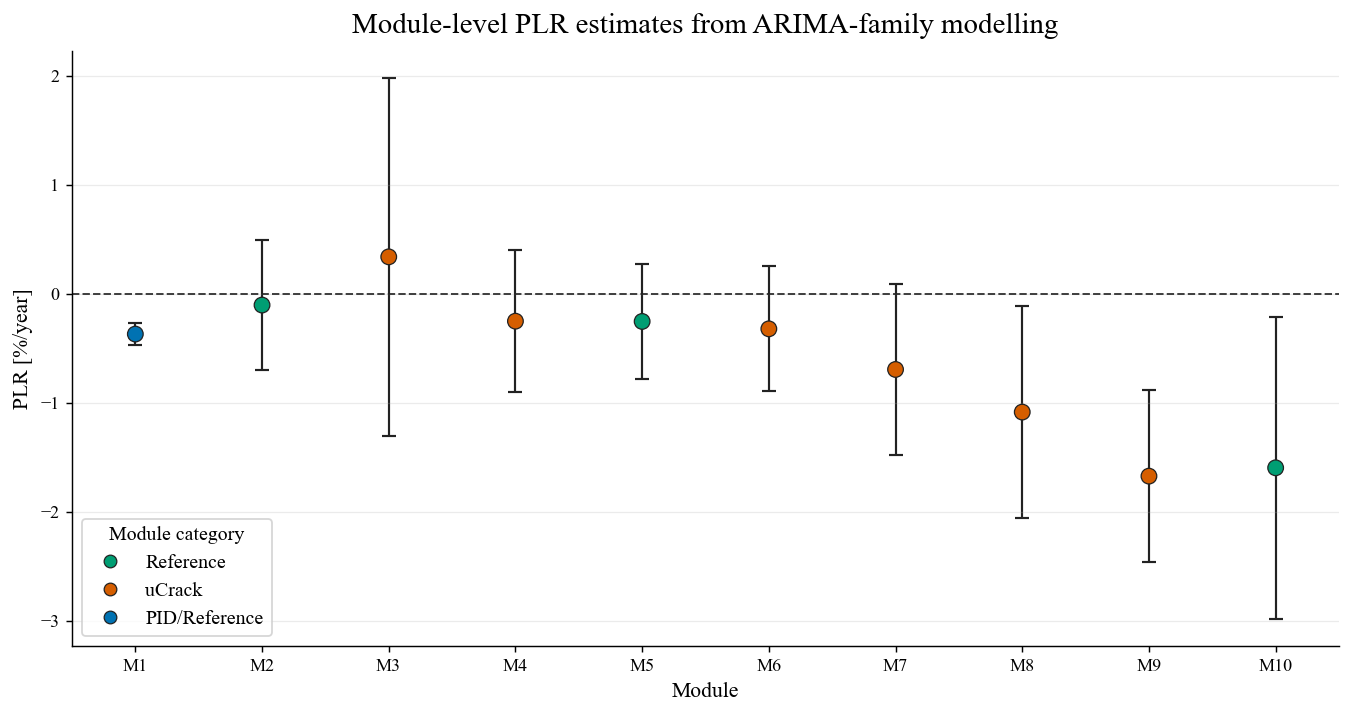

In [16]:
def plot_arima_module_level_plr(
    arima_main_results,
    save_name="arima_module_level_plr_estimates_g200.png",
):
    plot_df = arima_main_results.sort_values("Module_ID").copy()

    x = plot_df["Module_ID"].astype(int).to_numpy()
    y = plot_df["PLR_ARIMA_pct_per_year"].to_numpy()

    yerr_lower = y - plot_df["PLR_ARIMA_ci_low"].to_numpy()
    yerr_upper = plot_df["PLR_ARIMA_ci_high"].to_numpy() - y

    colors = plot_df["Type"].map(TYPE_COLORS).to_list()

    fig, ax = plt.subplots(figsize=(10.5, 5.6))

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor=BLACK,
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=1,
    )

    ax.scatter(
        x,
        y,
        s=75,
        c=colors,
        edgecolor=BLACK,
        linewidth=0.7,
        zorder=2,
    )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f"M{i}" for i in range(1, 11)])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Module-level PLR estimates from ARIMA-family modelling",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        handles=module_category_legend_handles(),
        title="Module category",
        loc="lower left",
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()
    save_fig(save_name, fig)
    plt.show()


plot_arima_module_level_plr(arima_main_results)

## 13. Plot fitted monthly ARIMA series

In [18]:
def arima_annotation_text(module_df):
    row = module_df.iloc[0]

    return (
        f"PLR = {row['PLR_ARIMA_pct_per_year']:.2f}%/year\n"
        f"95% CI [{row['PLR_ARIMA_ci_low']:.2f}, {row['PLR_ARIMA_ci_high']:.2f}]\n"
        f"Order {row['selected_order']}"
    )

In [19]:
def get_arima_plot_data(dataset_name=MAIN_DATASET):
    fitted = (
        arima_fitted
        .loc[arima_fitted["dataset"] == dataset_name]
        .copy()
    )

    results = (
        arima_results
        .loc[arima_results["dataset"] == dataset_name]
        .copy()
    )

    keep_cols = [
        "dataset",
        "Module_ID",
        "Type",
        "PLR_ARIMA_pct_per_year",
        "PLR_ARIMA_ci_low",
        "PLR_ARIMA_ci_high",
        "selected_order",
        "selected_seasonal_order",
        "n_months_imputed",
        "pct_months_imputed",
        "rmse_residual",
    ]

    merged = fitted.merge(
        results[keep_cols],
        on=["dataset", "Module_ID", "Type"],
        how="left",
    )

    return merged


arima_plot_data_g200 = get_arima_plot_data(MAIN_DATASET)

display(arima_plot_data_g200.head())

,Month_Start,PR_25C_arima,time_years,dataset,dataset_label,Module_ID,Type,module_color,arima_fitted_PR_25C,arima_residual,...,observed_month,imputed_for_arima,PLR_ARIMA_pct_per_year,PLR_ARIMA_ci_low,PLR_ARIMA_ci_high,selected_order,selected_seasonal_order,n_months_imputed,pct_months_imputed,rmse_residual
0,2017-01-01,0.993481,0.000000,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,#0072B2,0.986513,0.006968,...,True,False,-0.368709,-0.46636,-0.271057,"(2, 0, 1)","(0, 0, 0, 12)",16,27.586207,0.005884
1,2017-02-01,0.983843,0.084873,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,#0072B2,0.996999,-0.013156,...,False,True,-0.368709,-0.46636,-0.271057,"(2, 0, 1)","(0, 0, 0, 12)",16,27.586207,0.005884
2,2017-03-01,0.975139,0.161533,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,#0072B2,0.976590,-0.001452,...,False,True,-0.368709,-0.46636,-0.271057,"(2, 0, 1)","(0, 0, 0, 12)",16,27.586207,0.005884
3,2017-04-01,0.965501,0.246407,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,#0072B2,0.971555,-0.006055,...,True,False,-0.368709,-0.46636,-0.271057,"(2, 0, 1)","(0, 0, 0, 12)",16,27.586207,0.005884
4,2017-05-01,0.976131,0.328542,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,1,PID/Reference,#0072B2,0.966982,0.009149,...,True,False,-0.368709,-0.46636,-0.271057,"(2, 0, 1)","(0, 0, 0, 12)",16,27.586207,0.005884


Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_arima_fitted_monthly_prdc25c_g200.png


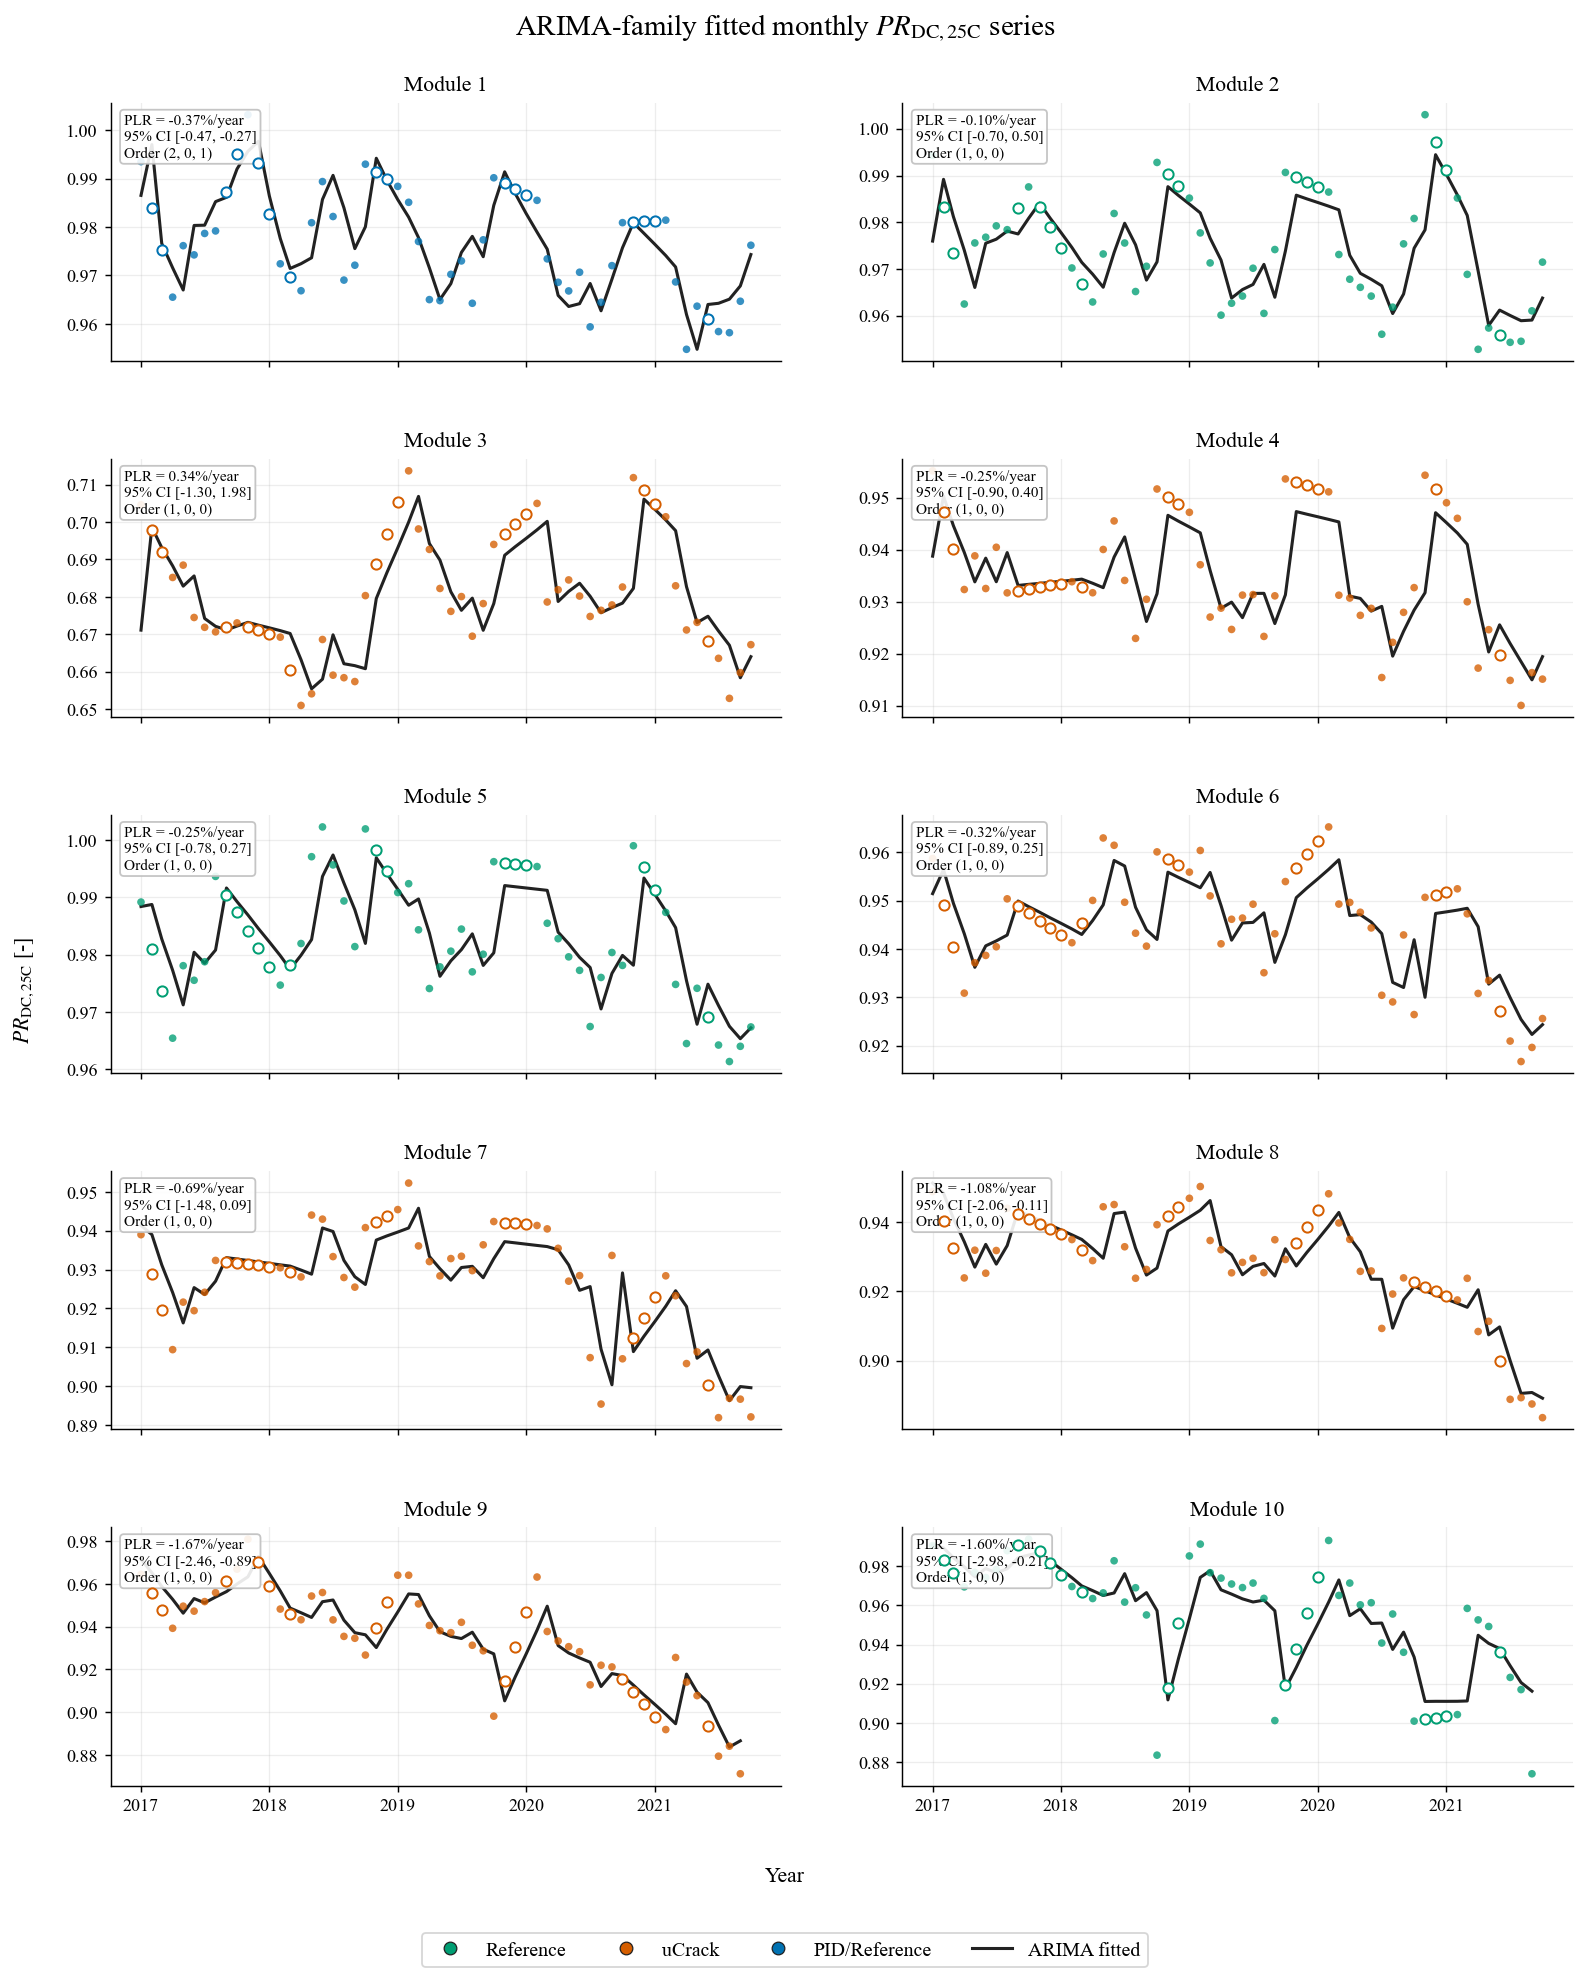

In [23]:
def plot_arima_fitted_series_all_modules(
    arima_plot_data,
    save_name="appendix_arima_fitted_monthly_prdc25c_g200.png",
):
    panel_df = arima_plot_data.copy()
    module_ids = sorted(panel_df["Module_ID"].unique())

    fig, axes = plt.subplots(
        nrows=5,
        ncols=2,
        figsize=(12.5, 15.5),
        sharex=True,
    )

    axes = axes.flatten()

    for ax, module_id in zip(axes, module_ids):
        module_df = (
            panel_df.loc[panel_df["Module_ID"] == module_id]
            .copy()
            .sort_values("Month_Start")
        )

        module_type = module_df["Type"].iloc[0]
        color = TYPE_COLORS[module_type]

        observed_df = module_df.loc[module_df["observed_month"]].copy()
        imputed_df = module_df.loc[module_df["imputed_for_arima"]].copy()

        ax.plot(
            module_df["Month_Start"],
            module_df["arima_fitted_PR_25C"],
            color=BLACK,
            linewidth=1.7,
            zorder=2,
            label="ARIMA fitted",
        )

        ax.scatter(
            observed_df["Month_Start"],
            observed_df["PR_25C_observed"],
            s=18,
            color=color,
            edgecolors="none",
            alpha=0.78,
            zorder=3,
        )

        ax.scatter(
            imputed_df["Month_Start"],
            imputed_df["PR_25C_arima"],
            s=32,
            facecolor="white",
            edgecolor=color,
            linewidth=1.1,
            alpha=1.0,
            zorder=4,
        )

        ax.set_title(
            f"Module {module_id}",
            fontsize=SUBTITLE_SIZE,
            pad=7,
        )

        format_year_axis(ax)

        ax.text(
            0.02,
            0.96,
            arima_annotation_text(module_df),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.5,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="#BFBFBF",
                alpha=0.90,
            ),
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        r"ARIMA-family fitted monthly $PR_\mathrm{DC,25C}$ series",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.supxlabel(
        "Year",
        fontsize=AXIS_LABEL_SIZE,
        y=0.055,
    )

    fig.supylabel(
        r"$PR_\mathrm{DC,25C}$ [-]",
        fontsize=AXIS_LABEL_SIZE,
        x=0.025,
    )

    fit_handles = [
        Line2D(
            [0],
            [0],
            color=BLACK,
            linewidth=1.7,
            label="ARIMA fitted",
        ),
    ]

    fig.legend(
        handles=module_category_legend_handles() + fit_handles,
        loc="lower center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
        fontsize=LEGEND_SIZE,
    )

    fig.subplots_adjust(
        left=0.085,     # increased from 0.075
        right=0.985,
        top=0.94,
        bottom=0.105,
        hspace=0.38,
        wspace=0.18,
    )

    save_fig(save_name, fig)
    plt.show()


plot_arima_fitted_series_all_modules(arima_plot_data_g200)

## 14. Plot ARIMA trend component

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_arima_trend_component_monthly_prdc25c_g200.png


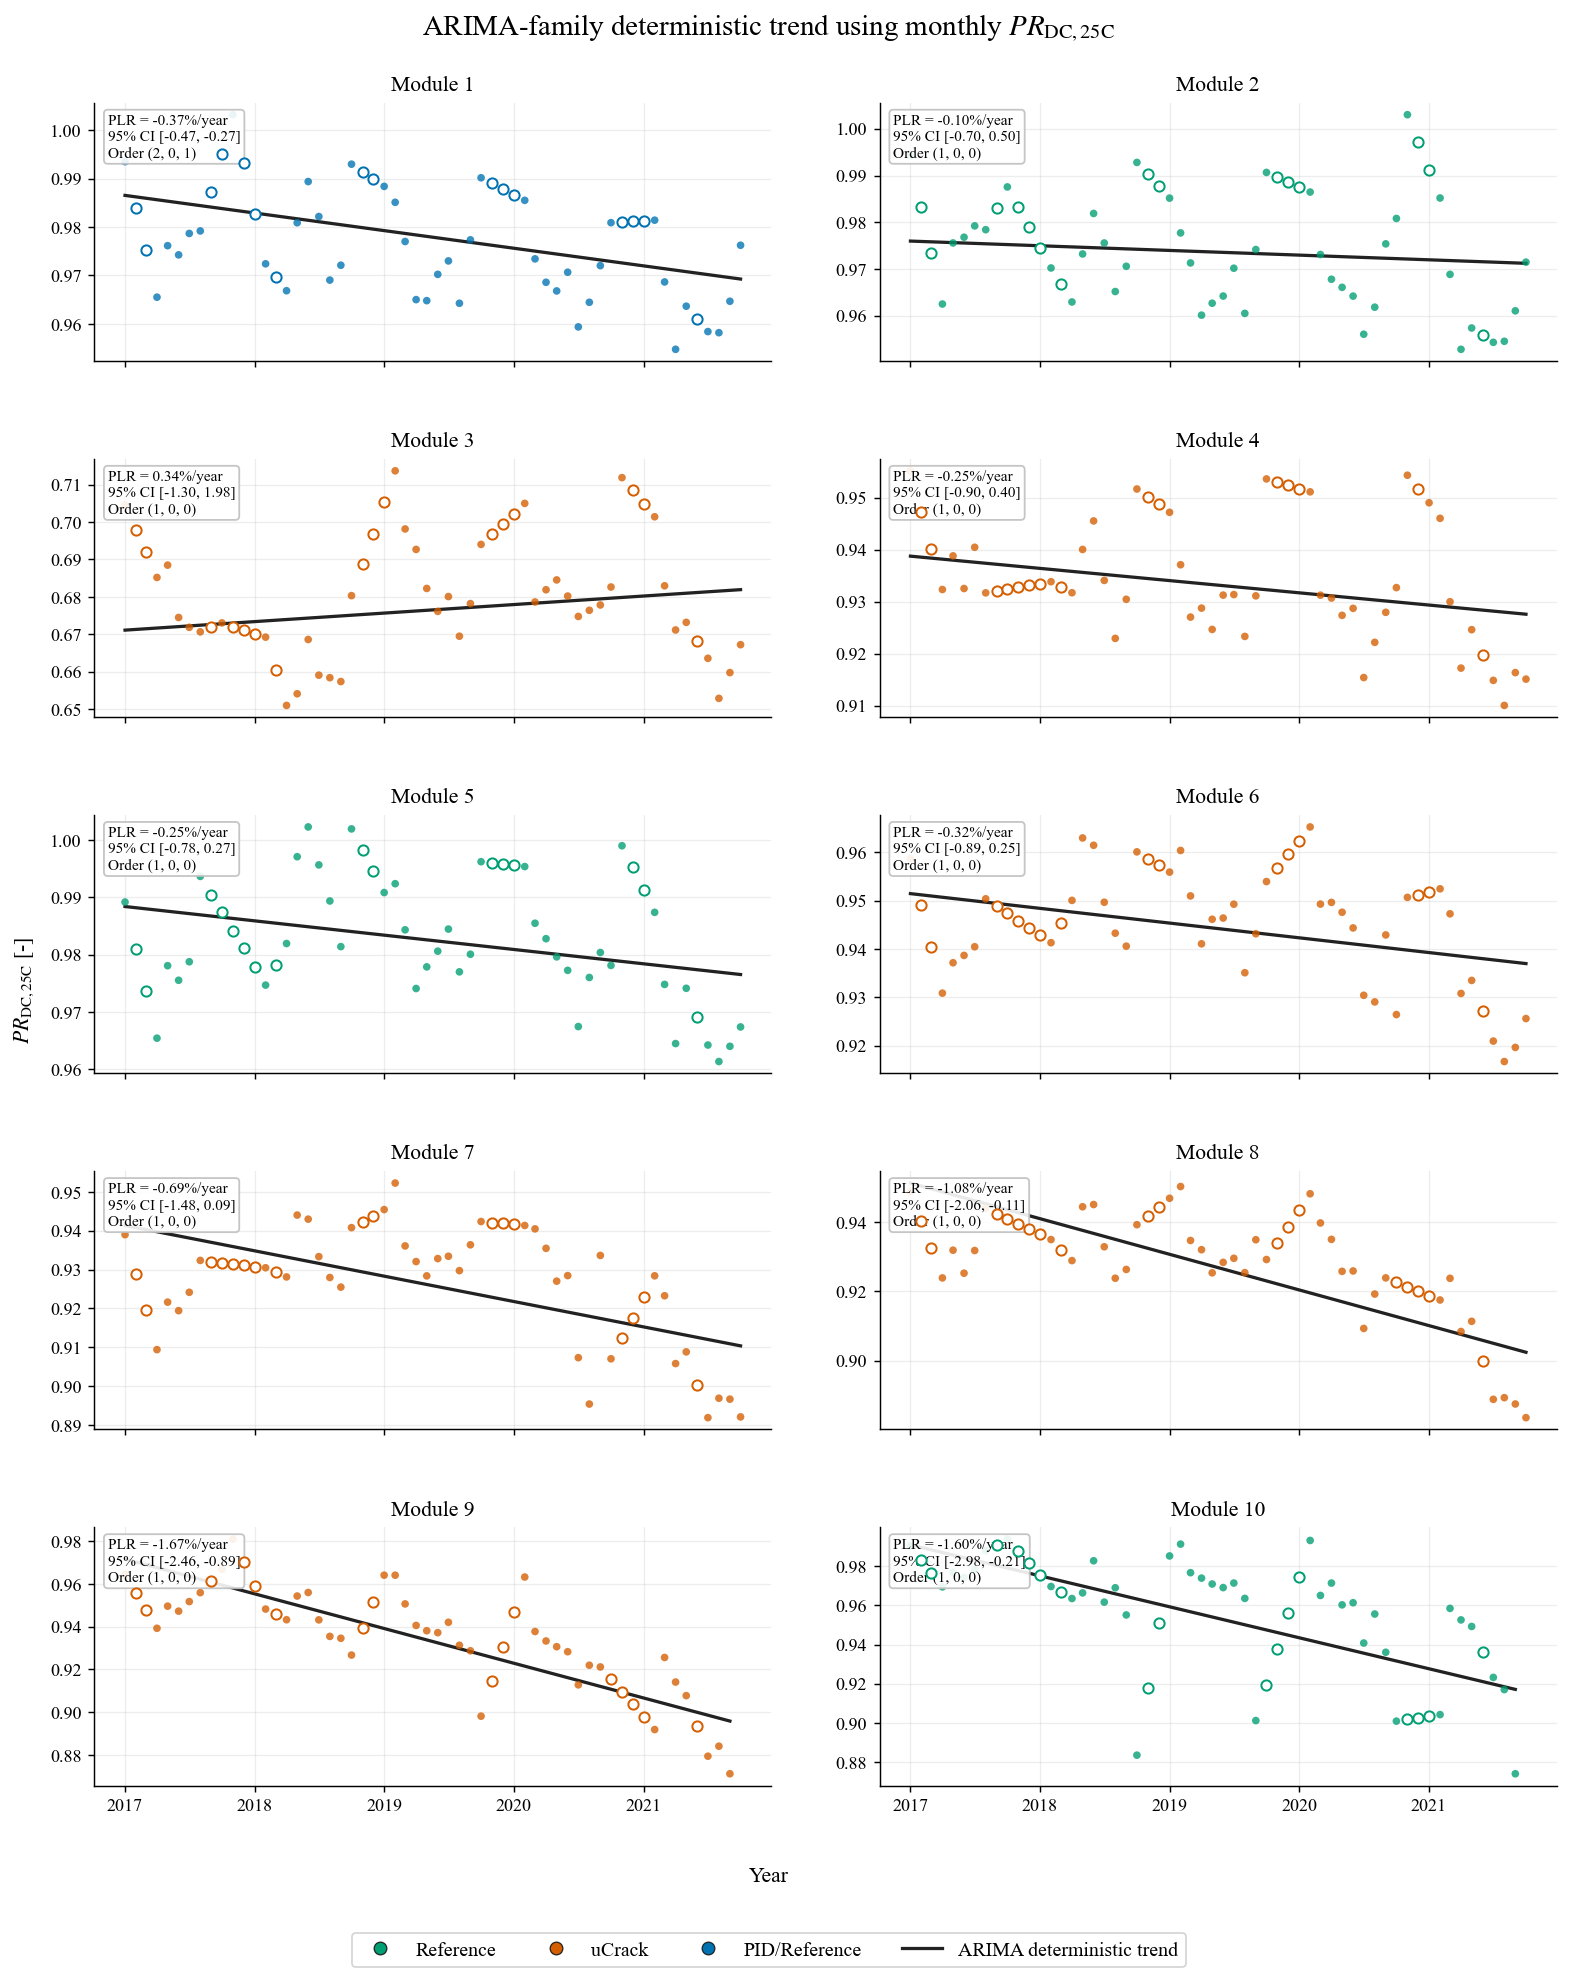

In [24]:
def plot_arima_trend_component_all_modules(
    arima_plot_data,
    save_name="appendix_arima_trend_component_monthly_prdc25c_g200.png",
):
    panel_df = arima_plot_data.copy()
    module_ids = sorted(panel_df["Module_ID"].unique())

    fig, axes = plt.subplots(
        nrows=5,
        ncols=2,
        figsize=(12.5, 15.5),
        sharex=True,
    )

    axes = axes.flatten()

    for ax, module_id in zip(axes, module_ids):
        module_df = (
            panel_df.loc[panel_df["Module_ID"] == module_id]
            .copy()
            .sort_values("Month_Start")
        )

        module_type = module_df["Type"].iloc[0]
        color = TYPE_COLORS[module_type]

        observed_df = module_df.loc[module_df["observed_month"]].copy()
        imputed_df = module_df.loc[module_df["imputed_for_arima"]].copy()

        ax.plot(
            module_df["Month_Start"],
            module_df["arima_trend_component"],
            color=BLACK,
            linewidth=1.8,
            zorder=2,
            label="ARIMA deterministic trend",
        )

        ax.scatter(
            observed_df["Month_Start"],
            observed_df["PR_25C_observed"],
            s=18,
            color=color,
            edgecolors="none",
            alpha=0.78,
            zorder=3,
        )

        ax.scatter(
            imputed_df["Month_Start"],
            imputed_df["PR_25C_arima"],
            s=32,
            facecolor="white",
            edgecolor=color,
            linewidth=1.1,
            alpha=1.0,
            zorder=4,
        )

        ax.set_title(f"Module {module_id}", fontsize=SUBTITLE_SIZE, pad=7)
        format_year_axis(ax)

        ax.text(
            0.02,
            0.96,
            arima_annotation_text(module_df),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.5,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="#BFBFBF",
                alpha=0.90,
            ),
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        r"ARIMA-family deterministic trend using monthly $PR_\mathrm{DC,25C}$",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.supxlabel("Year", fontsize=AXIS_LABEL_SIZE, y=0.055)
    fig.supylabel(
        r"$PR_\mathrm{DC,25C}$ [-]",
        fontsize=AXIS_LABEL_SIZE,
        x=0.035,
    )

    trend_handles = [
        Line2D([0], [0], color=BLACK, linewidth=1.8, label="ARIMA deterministic trend"),
    ]

    fig.legend(
        handles=module_category_legend_handles() + trend_handles,
        loc="lower center",
        ncol=4,
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
        fontsize=LEGEND_SIZE,
    )

    fig.subplots_adjust(
        left=0.085,
        right=0.985,
        top=0.94,
        bottom=0.105,
        hspace=0.38,
        wspace=0.16,
    )

    save_fig(save_name, fig)
    plt.show()


plot_arima_trend_component_all_modules(arima_plot_data_g200)

## 15. Residual diagnostics

In [25]:
arima_residual_summary = (
    arima_fitted
    .groupby(["dataset", "Module_ID", "Type"], as_index=False)
    .agg(
        mean_residual=("arima_residual", "mean"),
        median_residual=("arima_residual", "median"),
        median_abs_residual=("arima_residual", lambda x: x.abs().median()),
        rmse_residual=("arima_residual", lambda x: np.sqrt(np.mean(x ** 2))),
        max_abs_residual=("arima_residual", lambda x: x.abs().max()),
    )
)

display(arima_residual_summary)

ARIMA_RESIDUAL_SUMMARY_PATH = FINAL_TABLE_DIR / "arima_residual_summary.csv"

arima_residual_summary.to_csv(
    ARIMA_RESIDUAL_SUMMARY_PATH,
    index=False,
)

print("Saved residual summary:", ARIMA_RESIDUAL_SUMMARY_PATH)

,dataset,Module_ID,Type,mean_residual,median_residual,median_abs_residual,rmse_residual,max_abs_residual
0,g200,1,PID/Reference,-0.000386,-0.000040,0.003654,0.005884,0.014917
1,g200,2,Reference,0.000317,-0.000122,0.004529,0.008193,0.024644
2,g200,3,uCrack,0.000579,-0.000309,0.005312,0.009786,0.033517
3,g200,4,uCrack,0.000284,-0.000249,0.004803,0.007892,0.022607
4,g200,5,Reference,0.000016,-0.000407,0.003950,0.007031,0.020852
5,g200,6,uCrack,0.000127,0.000633,0.004376,0.007589,0.020695
6,g200,7,uCrack,-0.000038,-0.000780,0.004954,0.008822,0.033295
7,g200,8,uCrack,-0.000042,-0.000684,0.004623,0.006762,0.014898
8,g200,9,uCrack,-0.000122,-0.001715,0.006949,0.010518,0.031002
9,g200,10,Reference,-0.000004,0.000912,0.007843,0.018746,0.073765


Saved residual summary: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\arima_residual_summary.csv


Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_arima_residuals_g200.png


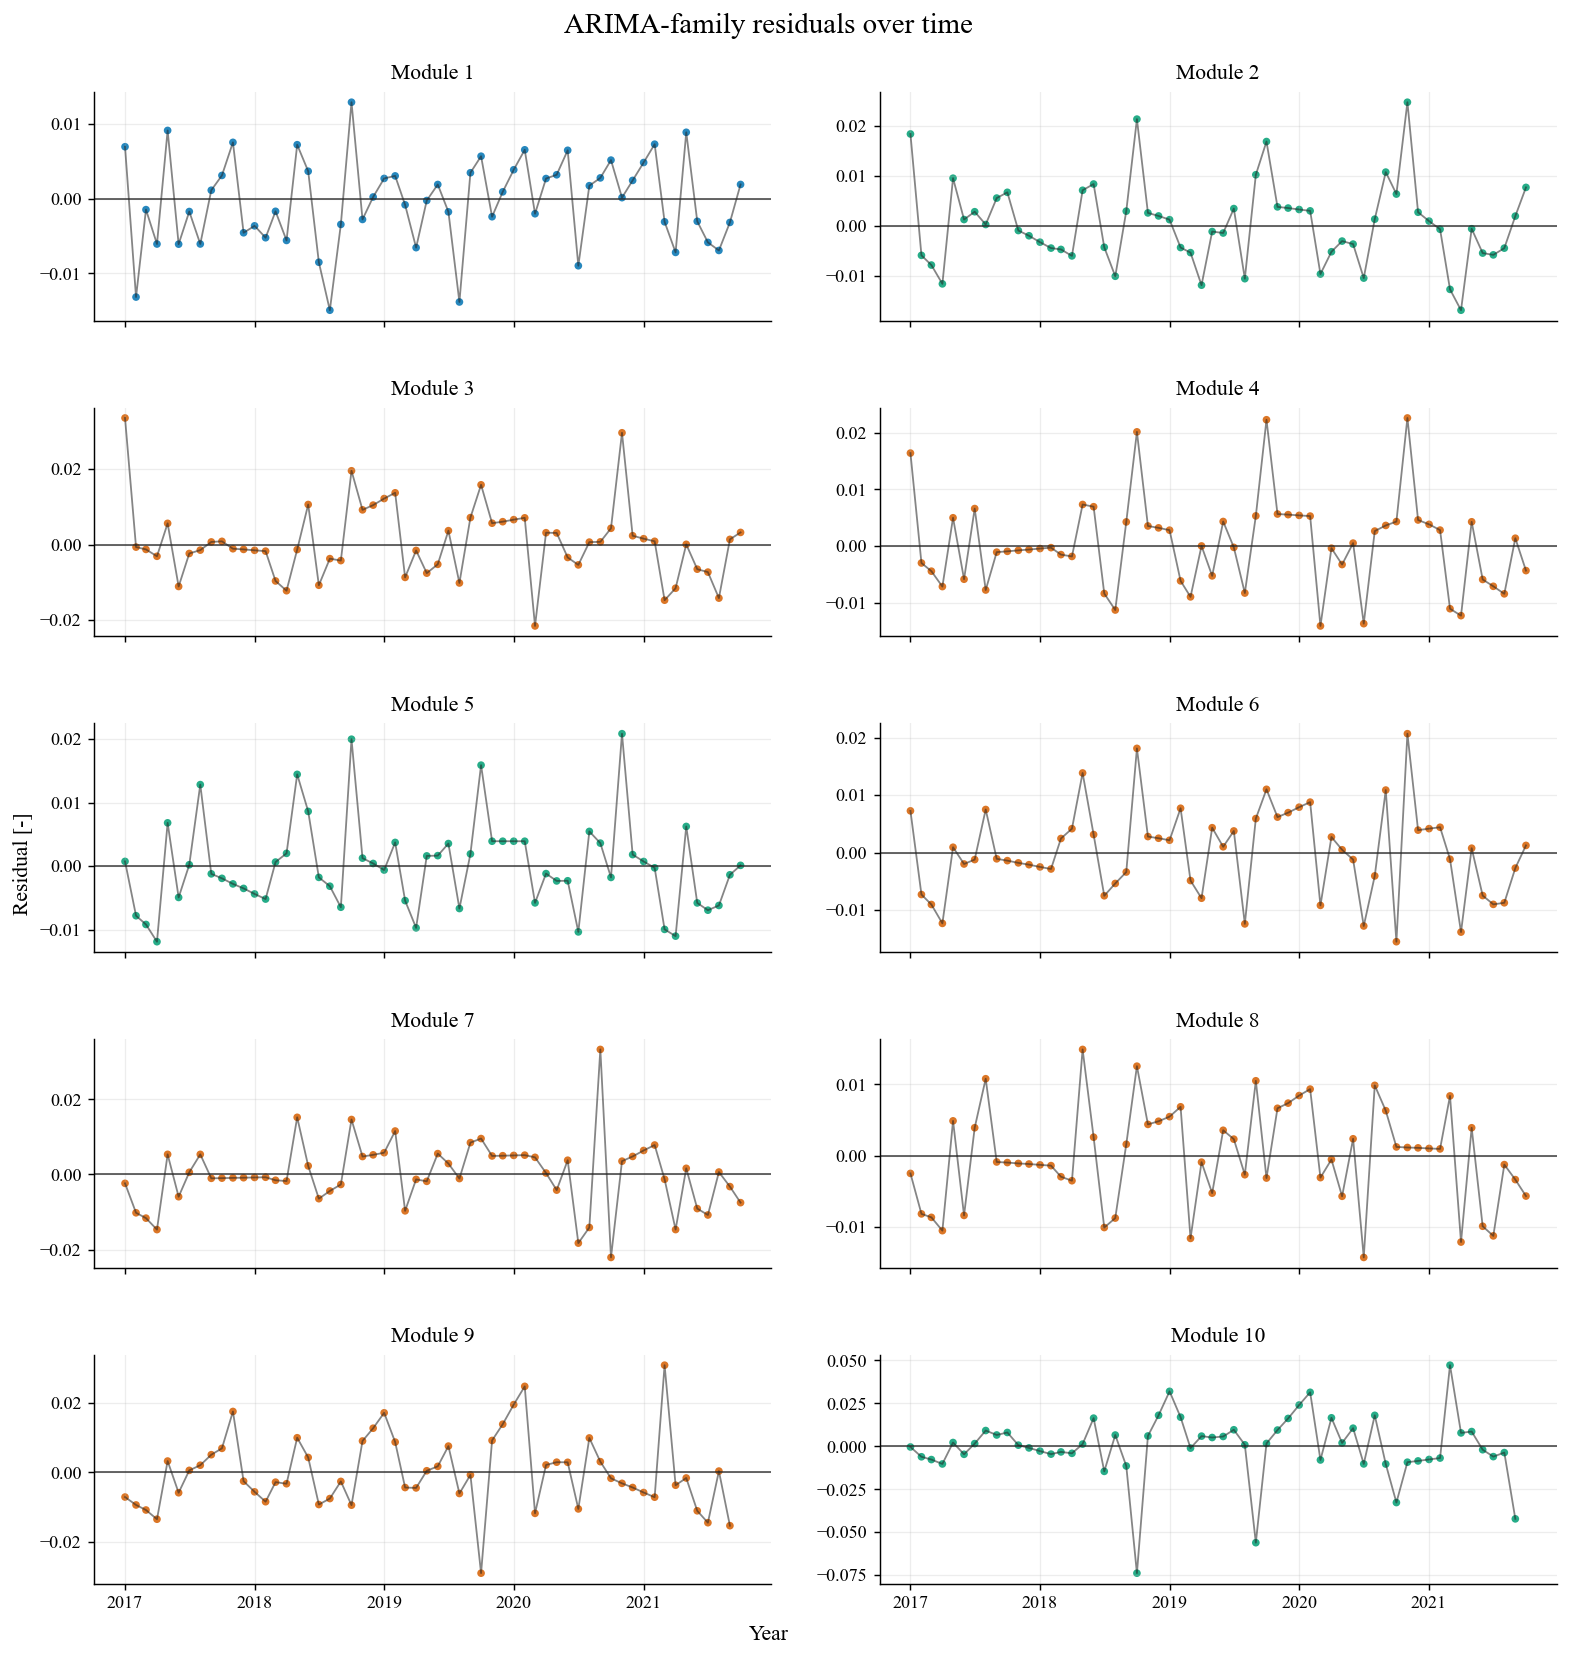

In [31]:
def plot_arima_residuals_all_modules(
    arima_fitted,
    dataset_name=MAIN_DATASET,
    save_name="appendix_arima_residuals_g200.png",
):
    resid_df = (
        arima_fitted
        .loc[arima_fitted["dataset"] == dataset_name]
        .copy()
        .sort_values(["Module_ID", "Month_Start"])
    )

    module_ids = sorted(resid_df["Module_ID"].unique())

    fig, axes = plt.subplots(
        nrows=5,
        ncols=2,
        figsize=(12.5, 13.5),
        sharex=True,
    )

    axes = axes.flatten()

    for ax, module_id in zip(axes, module_ids):
        module_df = resid_df.loc[resid_df["Module_ID"] == module_id].copy()

        module_type = module_df["Type"].iloc[0]
        color = TYPE_COLORS[module_type]

        ax.axhline(
            0,
            color=BLACK,
            linewidth=1.0,
            alpha=0.75,
        )

        ax.plot(
            module_df["Month_Start"],
            module_df["arima_residual"],
            color=BLACK,
            linewidth=1.0,
            alpha=0.55,
        )

        ax.scatter(
            module_df["Month_Start"],
            module_df["arima_residual"],
            s=18,
            color=color,
            edgecolors="none",
            alpha=0.85,
        )

        ax.set_title(f"Module {module_id}", fontsize=SUBTITLE_SIZE, pad=7)
        format_year_axis(ax)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        "ARIMA-family residuals over time",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.supxlabel("Year", fontsize=AXIS_LABEL_SIZE, y=0.055)
    fig.supylabel("Residual [-]", fontsize=AXIS_LABEL_SIZE, x=0.035)

    fig.subplots_adjust(
        left=0.085,
        right=0.985,
        top=0.94,
        bottom=0.09,
        hspace=0.38,
        wspace=0.16,
    )

    save_fig(save_name, fig)
    plt.show()


plot_arima_residuals_all_modules(arima_fitted)

## 16. Irradiance-threshold sensitivity

In [27]:
g200_results = (
    arima_results
    .loc[arima_results["dataset"] == MAIN_DATASET]
    .copy()
)

g400_results = (
    arima_results
    .loc[arima_results["dataset"] == SENSITIVITY_DATASET]
    .copy()
)

arima_irradiance_sensitivity = g200_results.merge(
    g400_results,
    on=["Module_ID", "Type"],
    suffixes=("_g200", "_g400"),
)

arima_irradiance_sensitivity["PLR_shift_g400_minus_g200"] = (
    arima_irradiance_sensitivity["PLR_ARIMA_pct_per_year_g400"]
    - arima_irradiance_sensitivity["PLR_ARIMA_pct_per_year_g200"]
)

arima_irradiance_sensitivity["abs_PLR_shift_g400_minus_g200"] = (
    arima_irradiance_sensitivity["PLR_shift_g400_minus_g200"].abs()
)

arima_irradiance_sensitivity_display = arima_irradiance_sensitivity[
    [
        "Module_ID",
        "Type",
        "selected_order_g200",
        "selected_seasonal_order_g200",
        "PLR_ARIMA_pct_per_year_g200",
        "PLR_ARIMA_ci_low_g200",
        "PLR_ARIMA_ci_high_g200",
        "selected_order_g400",
        "selected_seasonal_order_g400",
        "PLR_ARIMA_pct_per_year_g400",
        "PLR_ARIMA_ci_low_g400",
        "PLR_ARIMA_ci_high_g400",
        "PLR_shift_g400_minus_g200",
    ]
].copy()

display(arima_irradiance_sensitivity_display)

ARIMA_SENSITIVITY_PATH = FINAL_TABLE_DIR / "arima_irradiance_threshold_sensitivity_g400_minus_g200.csv"

arima_irradiance_sensitivity_display.to_csv(
    ARIMA_SENSITIVITY_PATH,
    index=False,
)

print("Saved ARIMA irradiance sensitivity table:", ARIMA_SENSITIVITY_PATH)

,Module_ID,Type,selected_order_g200,selected_seasonal_order_g200,PLR_ARIMA_pct_per_year_g200,PLR_ARIMA_ci_low_g200,PLR_ARIMA_ci_high_g200,selected_order_g400,selected_seasonal_order_g400,PLR_ARIMA_pct_per_year_g400,PLR_ARIMA_ci_low_g400,PLR_ARIMA_ci_high_g400,PLR_shift_g400_minus_g200
0,1,PID/Reference,"(2, 0, 1)","(0, 0, 0, 12)",-0.368709,-0.466360,-0.271057,"(1, 0, 0)","(0, 0, 0, 12)",-0.312665,-0.686380,0.061050,0.056044
1,2,Reference,"(1, 0, 0)","(0, 0, 0, 12)",-0.102688,-0.702185,0.496808,"(1, 0, 0)","(0, 0, 0, 12)",-0.291884,-1.041670,0.457901,-0.189196
2,3,uCrack,"(1, 0, 0)","(0, 0, 0, 12)",0.339654,-1.299834,1.979142,"(1, 0, 0)","(0, 0, 0, 12)",0.314140,-0.735179,1.363458,-0.025515
3,4,uCrack,"(1, 0, 0)","(0, 0, 0, 12)",-0.250568,-0.899897,0.398762,"(1, 0, 0)","(0, 0, 0, 12)",-0.364436,-0.814153,0.085282,-0.113868
4,5,Reference,"(1, 0, 0)","(0, 0, 0, 12)",-0.252889,-0.778343,0.272566,"(1, 0, 0)","(0, 0, 0, 12)",-0.578245,-1.049093,-0.107398,-0.325357
5,6,uCrack,"(1, 0, 0)","(0, 0, 0, 12)",-0.320805,-0.894843,0.253234,"(1, 0, 0)","(0, 0, 0, 12)",-0.599008,-1.164789,-0.033228,-0.278204
6,7,uCrack,"(1, 0, 0)","(0, 0, 0, 12)",-0.693458,-1.480250,0.093334,"(1, 0, 0)","(0, 0, 0, 12)",-0.909763,-1.813991,-0.005535,-0.216305
7,8,uCrack,"(1, 0, 0)","(0, 0, 0, 12)",-1.084372,-2.058902,-0.109842,"(1, 0, 0)","(0, 0, 0, 12)",-0.966787,-1.542503,-0.391071,0.117585
8,9,uCrack,"(1, 0, 0)","(0, 0, 0, 12)",-1.671927,-2.457465,-0.886389,"(1, 0, 0)","(0, 0, 0, 12)",-1.531851,-2.161125,-0.902577,0.140076
9,10,Reference,"(1, 0, 0)","(0, 0, 0, 12)",-1.595494,-2.983207,-0.207781,"(1, 0, 0)","(0, 0, 0, 12)",-0.930683,-1.314621,-0.546745,0.664812


Saved ARIMA irradiance sensitivity table: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\arima_irradiance_threshold_sensitivity_g400_minus_g200.csv


## 17. Prepare ensemble-ready ARIMA results

In [28]:
arima_for_ensemble = arima_results.copy()

arima_for_ensemble["method"] = "ARIMA"
arima_for_ensemble["method_role"] = "Robustness check"
arima_for_ensemble["metric"] = "PR_DC,25C"
arima_for_ensemble["aggregation"] = "Monthly"
arima_for_ensemble["is_main_dataset"] = arima_for_ensemble["dataset"].eq(MAIN_DATASET)

arima_for_ensemble = arima_for_ensemble.rename(
    columns={
        "PLR_ARIMA_pct_per_year": "PLR_pct_per_year",
        "PLR_ARIMA_ci_low": "PLR_ci_low",
        "PLR_ARIMA_ci_high": "PLR_ci_high",
    }
)

ensemble_cols = [
    "method",
    "method_role",
    "dataset",
    "dataset_label",
    "is_main_dataset",
    "metric",
    "aggregation",
    "Module_ID",
    "Type",
    "n_months_regular",
    "n_months_observed",
    "n_months_imputed",
    "pct_months_imputed",
    "first_month",
    "last_month",
    "PLR_pct_per_year",
    "PLR_ci_low",
    "PLR_ci_high",
    "slope_per_year",
    "slope_se",
    "slope_p_value",
    "intercept",
    "selected_order",
    "selected_seasonal_order",
    "aic",
    "bic",
    "rmse_residual",
    "median_abs_residual",
    "mean_residual",
    "n_converged_candidates",
    "n_total_candidates",
]

arima_for_ensemble = (
    arima_for_ensemble[ensemble_cols]
    .sort_values(["dataset", "Module_ID"])
    .reset_index(drop=True)
)

display(arima_for_ensemble)

,method,method_role,dataset,dataset_label,is_main_dataset,metric,aggregation,Module_ID,Type,n_months_regular,...,intercept,selected_order,selected_seasonal_order,aic,bic,rmse_residual,median_abs_residual,mean_residual,n_converged_candidates,n_total_candidates
0,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,1,PID/Reference,58,...,0.986513,"(2, 0, 1)","(0, 0, 0, 12)",-377.146321,-364.783663,0.005884,0.003654,-0.000386,34,36
1,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,2,Reference,58,...,0.975970,"(1, 0, 0)","(0, 0, 0, 12)",-366.450642,-358.208870,0.008193,0.004529,0.000317,32,36
2,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,3,uCrack,58,...,0.671107,"(1, 0, 0)","(0, 0, 0, 12)",-353.926373,-345.684601,0.009786,0.005312,0.000579,31,36
3,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,4,uCrack,58,...,0.938733,"(1, 0, 0)","(0, 0, 0, 12)",-369.993203,-361.751431,0.007892,0.004803,0.000284,31,36
4,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,5,Reference,58,...,0.988391,"(1, 0, 0)","(0, 0, 0, 12)",-378.754009,-370.512237,0.007031,0.003950,0.000016,32,36
5,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,6,uCrack,58,...,0.951475,"(1, 0, 0)","(0, 0, 0, 12)",-370.940048,-362.698276,0.007589,0.004376,0.000127,32,36
6,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,7,uCrack,58,...,0.941363,"(1, 0, 0)","(0, 0, 0, 12)",-352.951208,-344.709436,0.008822,0.004954,-0.000038,32,36
7,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,8,uCrack,58,...,0.951377,"(1, 0, 0)","(0, 0, 0, 12)",-383.311938,-375.070166,0.006762,0.004623,-0.000042,35,36
8,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,9,uCrack,57,...,0.971586,"(1, 0, 0)","(0, 0, 0, 12)",-327.010610,-318.838405,0.010518,0.006949,-0.000122,36,36
9,ARIMA,Robustness check,g200,$G_\mathrm{POA} \geq 200$ W/m$^2$,True,"PR_DC,25C",Monthly,10,Reference,57,...,0.990857,"(1, 0, 0)","(0, 0, 0, 12)",-261.832572,-253.660367,0.018746,0.007843,-0.000004,34,36


In [29]:
ARIMA_ENSEMBLE_CSV_PATH = FINAL_TABLE_DIR / "arima_for_ensemble.csv"
ARIMA_ENSEMBLE_PARQUET_PATH = ARIMA_OUTPUT_DIR / "arima_for_ensemble.parquet"

arima_for_ensemble.to_csv(ARIMA_ENSEMBLE_CSV_PATH, index=False)
arima_for_ensemble.to_parquet(ARIMA_ENSEMBLE_PARQUET_PATH, index=False)

print("Saved ensemble-ready ARIMA CSV:", ARIMA_ENSEMBLE_CSV_PATH)
print("Saved ensemble-ready ARIMA parquet:", ARIMA_ENSEMBLE_PARQUET_PATH)

Saved ensemble-ready ARIMA CSV: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\arima_for_ensemble.csv
Saved ensemble-ready ARIMA parquet: C:\Users\amina\Thesis\Final Pipeline\data_processed\arima_outputs\arima_for_ensemble.parquet


## 18. Save final ARIMA outputs

In [30]:
ARIMA_RESULTS_PATH = FINAL_TABLE_DIR / "arima_plr_estimates_all_datasets.csv"
ARIMA_MAIN_RESULTS_PATH = FINAL_TABLE_DIR / "arima_plr_estimates_g200.csv"
ARIMA_CANDIDATES_PATH = ARIMA_OUTPUT_DIR / "arima_candidate_results_all_datasets.parquet"
ARIMA_FITTED_PATH = ARIMA_OUTPUT_DIR / "arima_fitted_outputs_all_datasets.parquet"

arima_results.to_csv(ARIMA_RESULTS_PATH, index=False)
arima_main_results.to_csv(ARIMA_MAIN_RESULTS_PATH, index=False)
arima_candidate_results.to_parquet(ARIMA_CANDIDATES_PATH, index=False)
arima_fitted.to_parquet(ARIMA_FITTED_PATH, index=False)

print("Saved ARIMA results:", ARIMA_RESULTS_PATH)
print("Saved main ARIMA results:", ARIMA_MAIN_RESULTS_PATH)
print("Saved candidate results:", ARIMA_CANDIDATES_PATH)
print("Saved fitted outputs:", ARIMA_FITTED_PATH)

Saved ARIMA results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\arima_plr_estimates_all_datasets.csv
Saved main ARIMA results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\arima_plr_estimates_g200.csv
Saved candidate results: C:\Users\amina\Thesis\Final Pipeline\data_processed\arima_outputs\arima_candidate_results_all_datasets.parquet
Saved fitted outputs: C:\Users\amina\Thesis\Final Pipeline\data_processed\arima_outputs\arima_fitted_outputs_all_datasets.parquet
